# Adam vs SGD Convergence (B4)

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from network import Network, NetworkConfig
from optimizer import Adam, Sgd

Adam (lr=0.001): final loss = 0.001991
SGD (lr=0.01): final loss = 0.284359


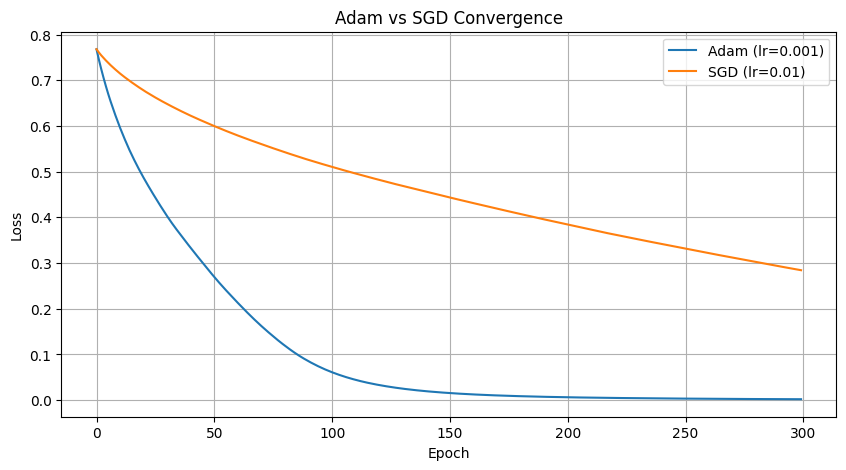

In [2]:
np.random.seed(42)
x = np.random.randn(50, 30)
y = np.zeros((50, 2))
y[np.arange(50), np.random.randint(0, 2, 50)] = 1

plt.figure(figsize=(10, 5))

for name, Opt, lr in [('Adam (lr=0.001)', Adam, 0.001), ('SGD (lr=0.01)', Sgd, 0.01)]:
    np.random.seed(42)
    net = Network(NetworkConfig(layers=[30, 24, 24, 24, 2], activation='relu',
        loss='cross_entropy', output_activation='softmax', weights_initializer='heUniform'))
    opt = Opt(learning_rate=lr)
    losses = []
    for _ in range(300):
        out = net.forward(x)
        losses.append(net.loss(y, out))
        nw, nb = net.backward(y)
        opt.update(net, nw, nb)
    print(f'{name}: final loss = {losses[-1]:.6f}')
    plt.plot(losses, label=name)

plt.title('Adam vs SGD Convergence')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.show()